# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

# Configuración para que los gráficos se vean bien en el notebook
%matplotlib inline
sns.set(style="whitegrid")

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [2]:
df = pd.read_csv('data/comprar_alquilar.csv')

In [3]:
df

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...
197,3831,690,352,488,10723,363120,0,0,2,0
198,3961,1030,270,475,21880,280421,2,3,8,0
199,3184,955,276,684,35565,388025,1,3,8,0
200,3334,867,369,652,19985,376892,1,2,5,0


In [4]:
from src.mi_eda import eda

### 📋 Muestra

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...
197,3831,690,352,488,10723,363120,0,0,2,0
198,3961,1030,270,475,21880,280421,2,3,8,0
199,3184,955,276,684,35565,388025,1,3,8,0
200,3334,867,369,652,19985,376892,1,2,5,0


### 📊 Info → `202` filas × `10` columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB
None


#### Uniques

ingresos          199
gastos_comunes    188
pago_coche        160
gastos_otros      175
ahorros           202
vivienda          202
estado_civil        3
hijos               5
trabajo             9
comprar             2
dtype: int64


### ⚠️ Null & NaN

ingresos          0
gastos_comunes    0
pago_coche        0
gastos_otros      0
ahorros           0
vivienda          0
estado_civil      0
hijos             0
trabajo           0
comprar           0
dtype: int64


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar


### 📦 Describe

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000,202.000,202.000,202.000,202.000,202.000,202.000,202.000,202.000,202.000
mean,4958.995,971.584,211.743,515.426,38749.668,373349.639,1.025,1.233,4.490,0.332
std,1682.863,272.106,124.941,168.103,17365.232,136371.526,0.837,1.368,2.536,0.472
min,2008.000,384.000,0.000,201.000,10319.000,176553.000,0.000,0.000,0.000,0.000
25%,3513.750,766.750,99.000,383.250,24964.250,274810.000,0.000,0.000,2.000,0.000
50%,4947.500,968.000,208.500,522.500,38523.000,340783.500,1.000,1.000,5.000,0.000
75%,6374.500,1165.250,318.750,656.750,52150.750,444482.000,2.000,2.000,7.000,1.000
max,7984.000,1585.000,448.000,828.000,69934.000,669540.000,2.000,4.000,8.000,1.000


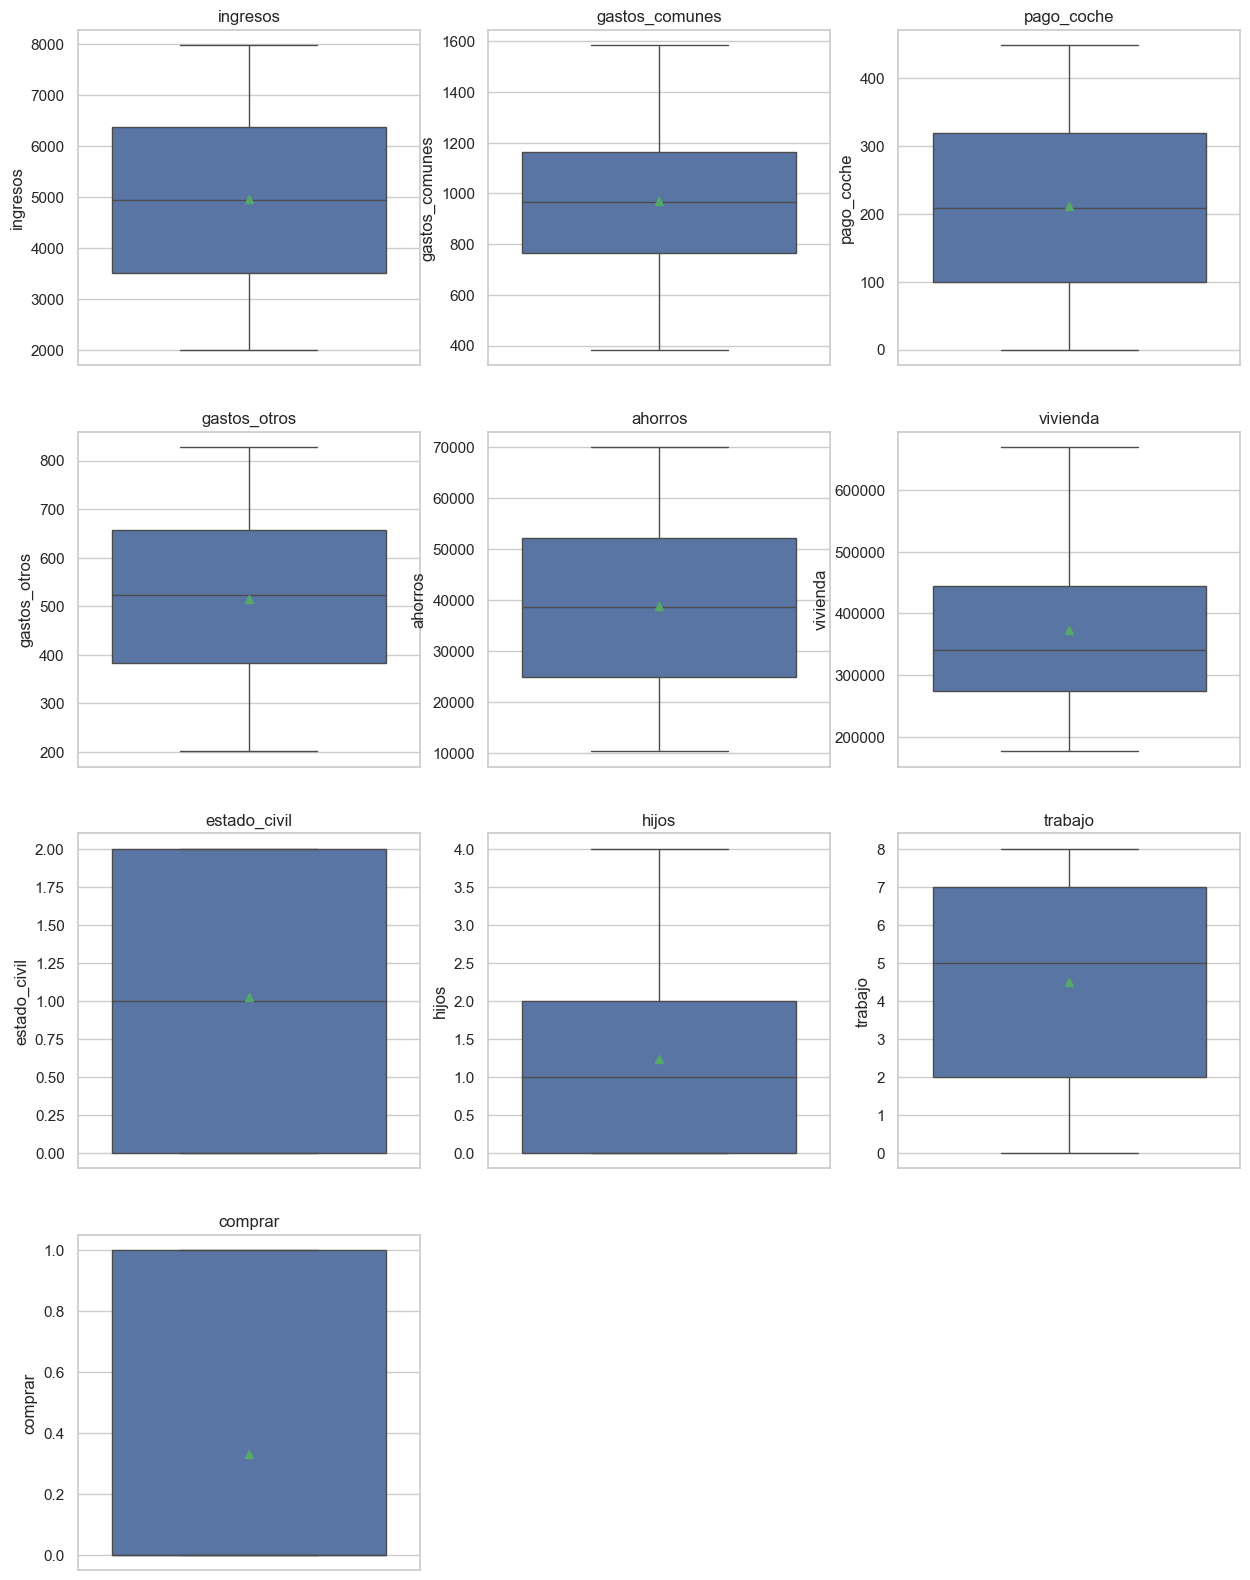

### 📈 Comparación

### (target: comprar)

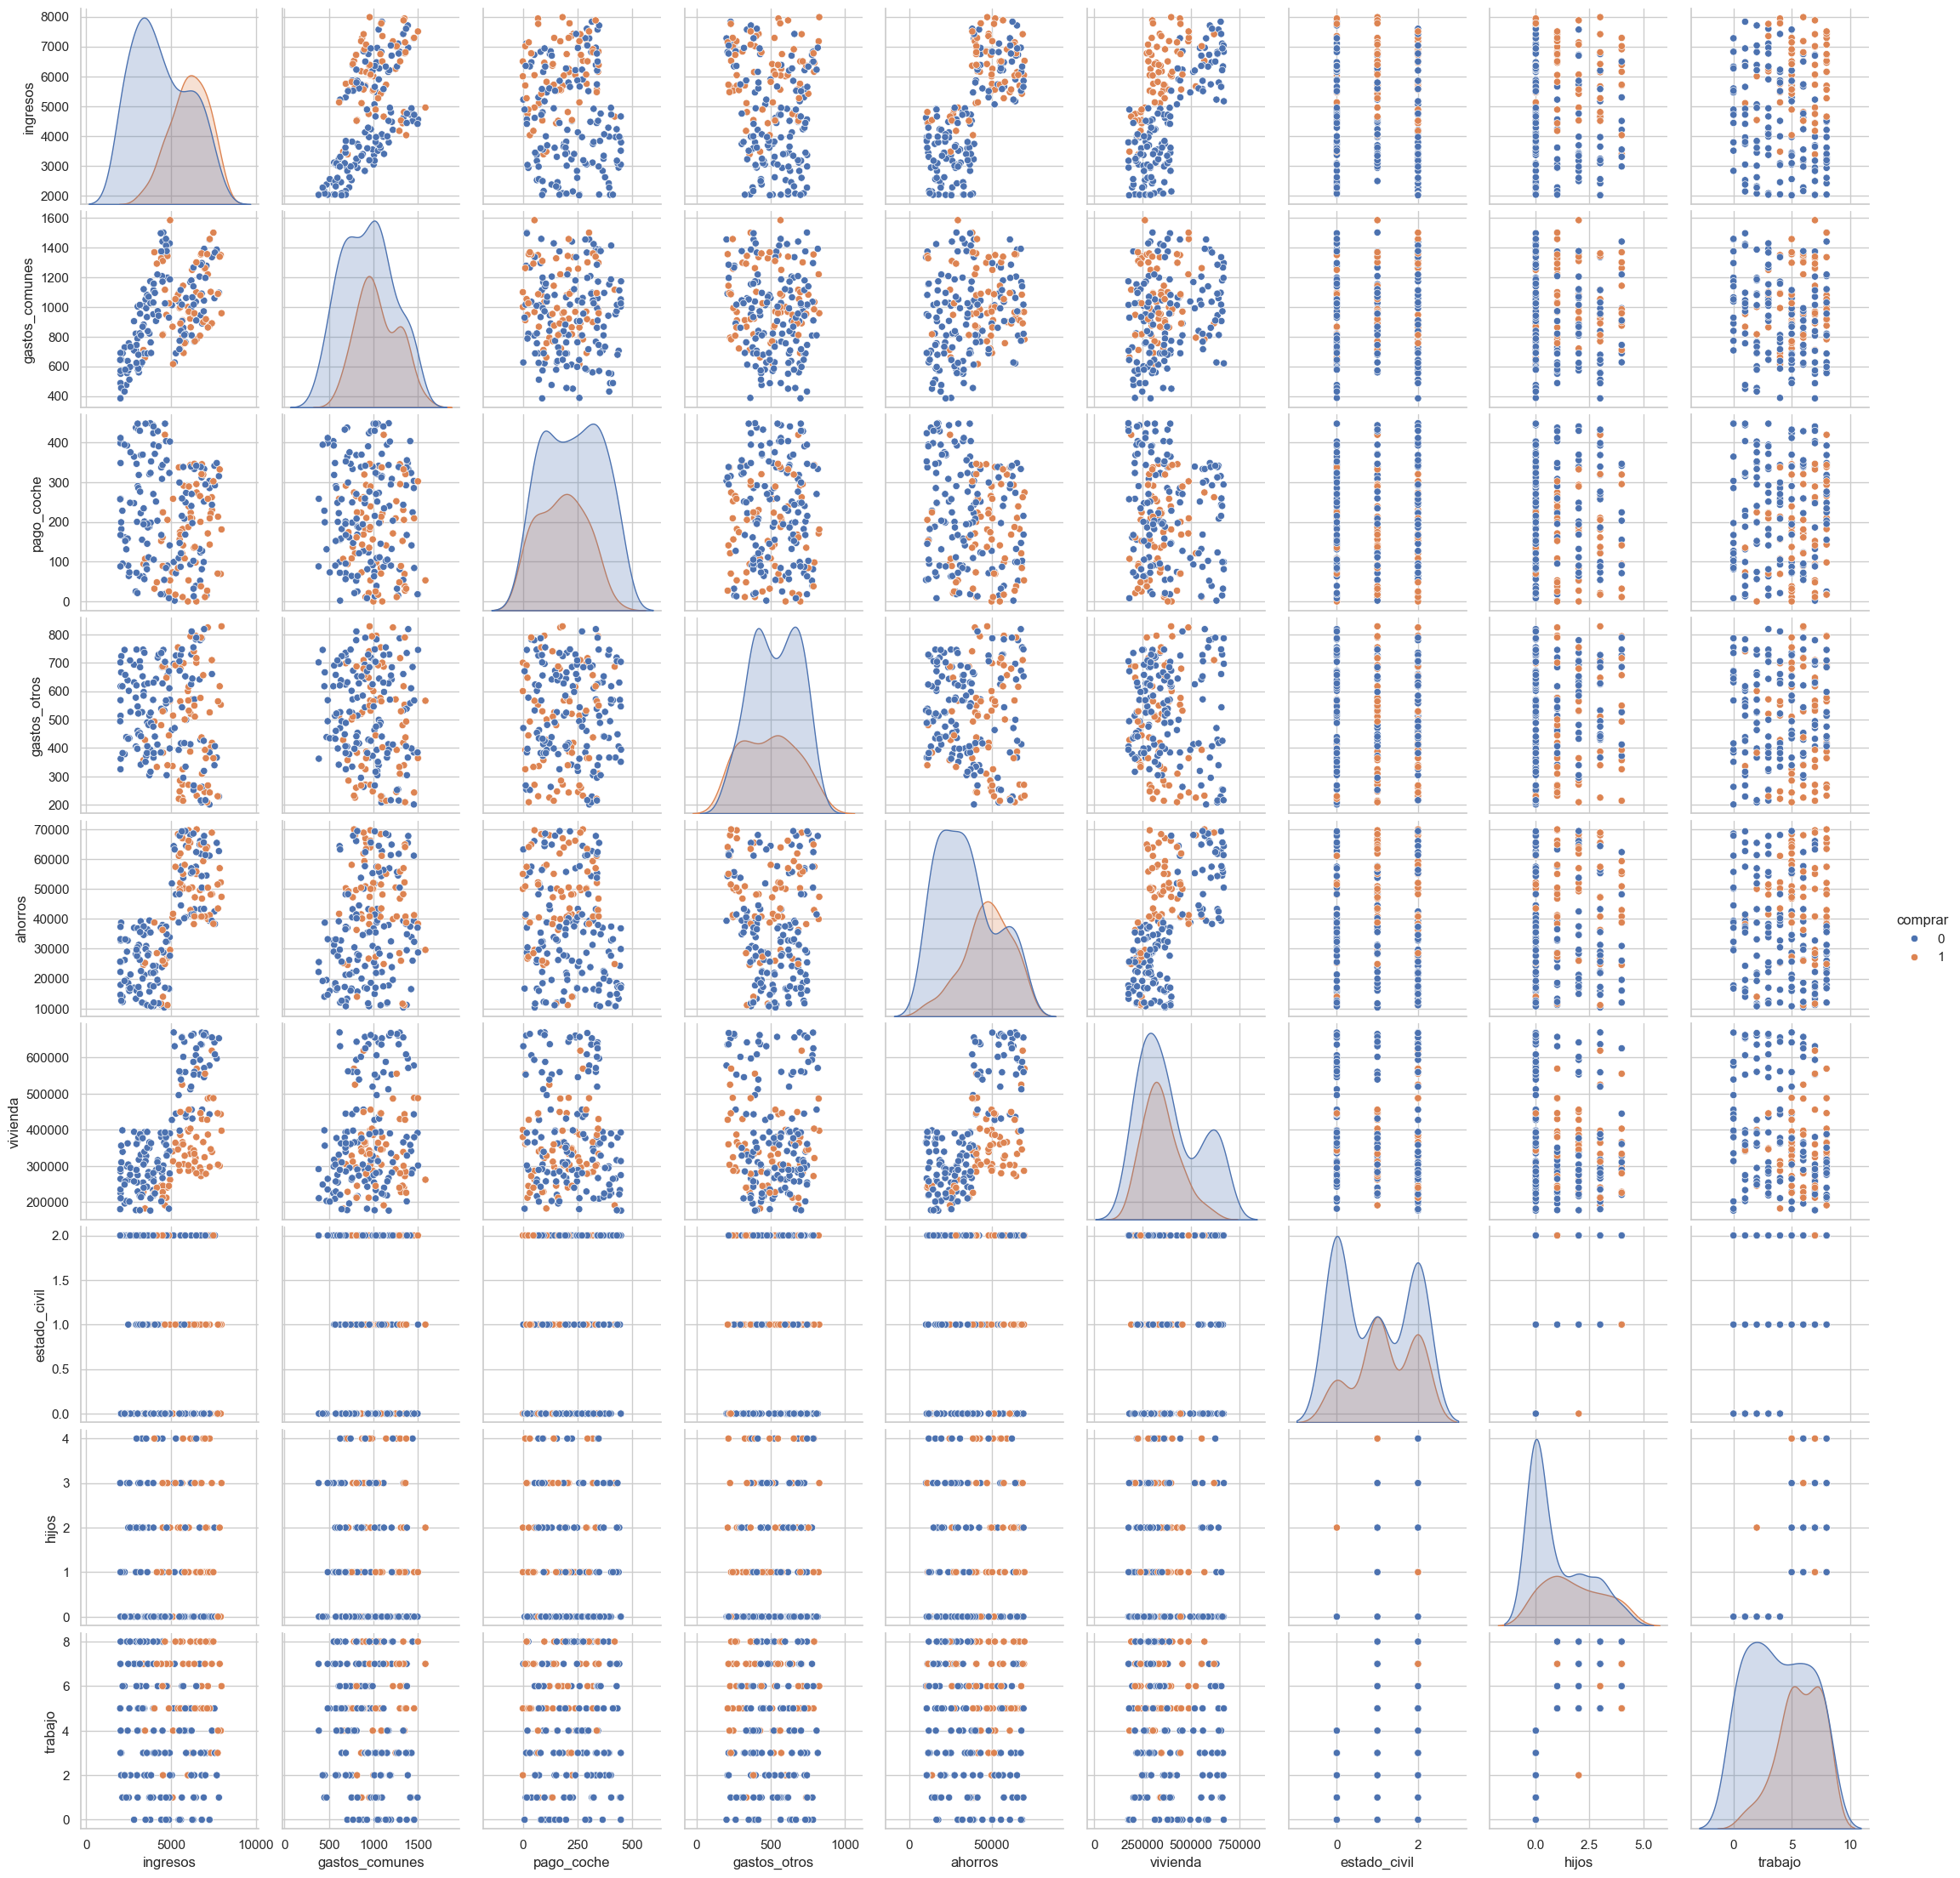

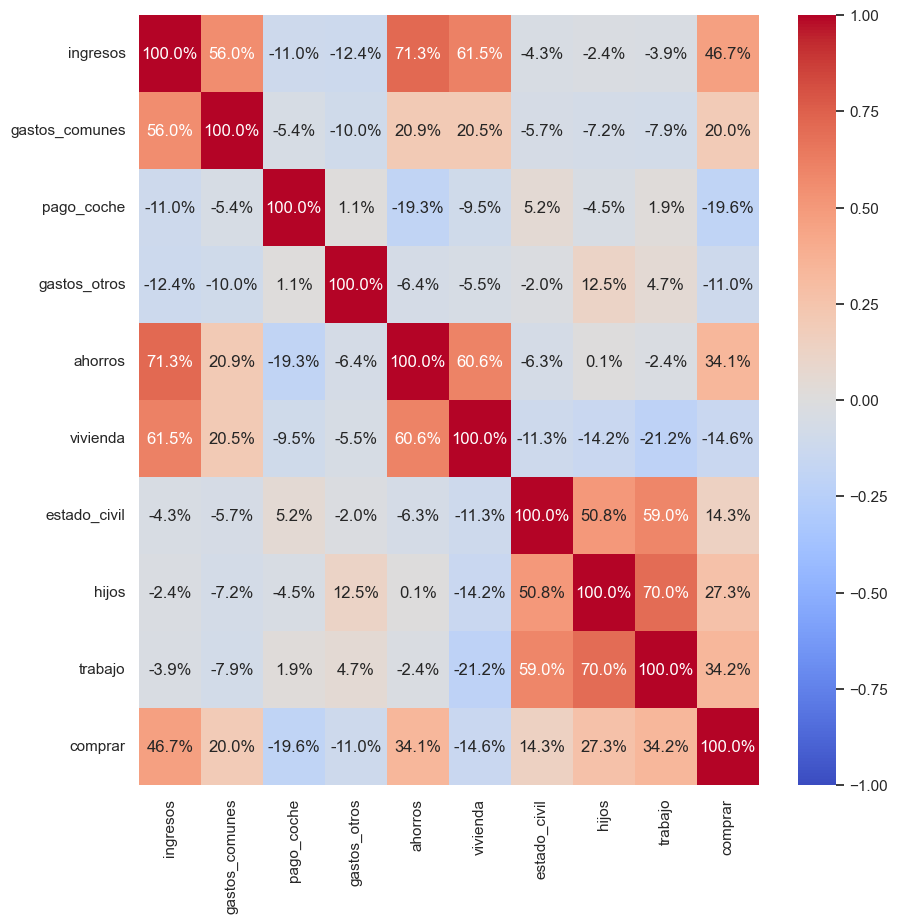

In [5]:
eda(df, df['comprar'])

### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

C:\Users\Varushet\AppData\Local\Temp\ipykernel_13712\861228854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='comprar', y=col, data=df, ax=axes[i], palette="viridis")
C:\Users\Varushet\AppData\Local\Temp\ipykernel_13712\861228854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='comprar', y=col, data=df, ax=axes[i], palette="viridis")
C:\Users\Varushet\AppData\Local\Temp\ipykernel_13712\861228854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='comprar', y=col, data=df, ax=axes[i], palette="viridis")
C:\Users\Varushet\A

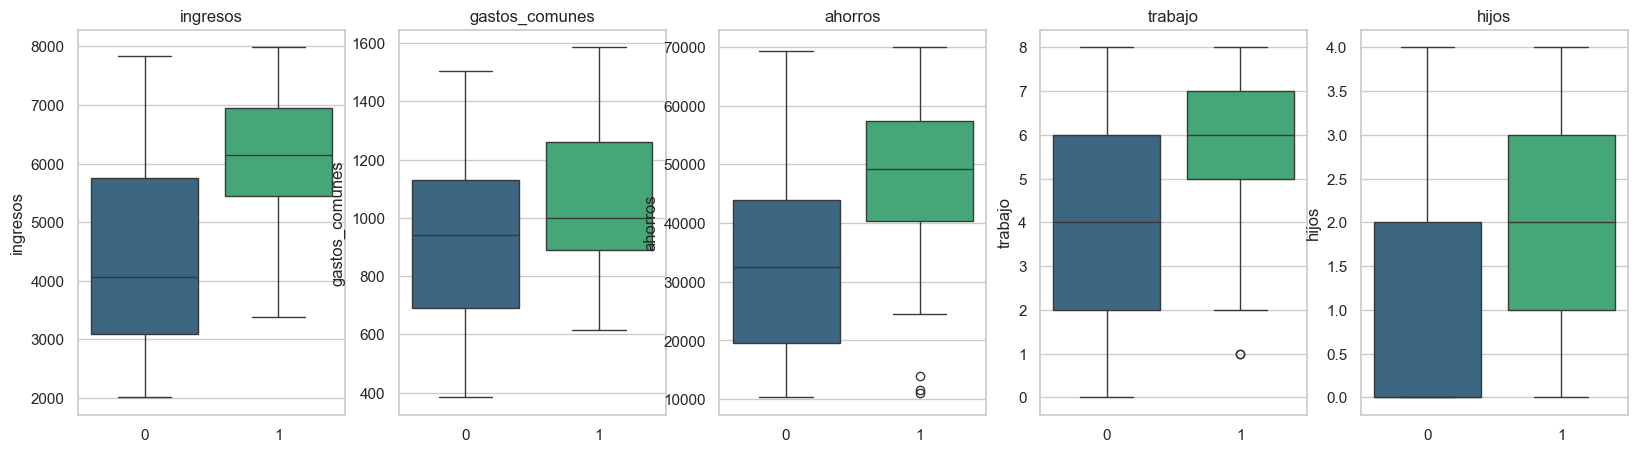

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos las variables que quieres analizar
vars_interes = ['ingresos', 'gastos_comunes', 'ahorros', 'trabajo', 'hijos']

# 2. Configuramos la gráfica: 1 fila, 5 columnas
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# 3. Bucle para generar cada boxplot
for i, col in enumerate(vars_interes):
    # Verificamos que la columna exista para evitar errores
    if col in df.columns:
        sns.boxplot(x='comprar', y=col, data=df, ax=axes[i], palette="viridis")
        axes[i].set_title(col)
        axes[i].set_xlabel('') # Quitamos etiqueta x para limpiar visualmente
        
plt.show()

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [7]:
features = df.select_dtypes(include=[np.number])
target = df['comprar']

In [ ]:
X_scaled = StandardScaler().fit_transform(features)

In [12]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features.columns)
X_scaled_df

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,0.620129,0.104689,-1.698954,0.504359,0.649475,0.195910,-1.227088,0.562374,-0.984420,1.419481
1,1.063927,-0.101625,-0.712042,-0.515401,0.259224,1.937370,-0.029640,1.295273,0.596915,-0.704483
2,0.891173,0.226266,-0.912634,1.667244,1.080309,-0.379102,1.167809,-0.170526,1.387582,1.419481
3,1.274209,1.128886,-1.578599,-1.559015,0.909604,2.114062,-1.227088,-0.903426,-0.589086,-0.704483
4,0.719611,-0.400042,0.090326,0.027279,0.159468,-0.179497,-1.227088,-0.903426,-0.589086,1.419481
...,...,...,...,...,...,...,...,...,...,...
197,-0.671949,-1.037402,1.125381,-0.163554,-1.617963,-0.075199,-1.227088,-0.903426,-0.984420,-0.704483
198,-0.594508,0.215214,0.467439,-0.241079,-0.973876,-0.683130,1.167809,1.295273,1.387582,-0.704483
199,-1.057368,-0.061099,0.515581,1.005294,-0.183849,0.107880,-0.029640,1.295273,1.387582,-0.704483
200,-0.968013,-0.385305,1.261783,0.814462,-1.083273,0.026040,-0.029640,0.562374,0.201581,-0.704483


## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [14]:
n_components = X_scaled_df.shape[1]
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(X_scaled_df)

In [16]:
pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
print("Resultado PCA (primeras filas):")
pca_df.head()

Resultado PCA (primeras filas):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1.535449,0.068159,-0.545565,-2.179020,0.355643,-0.348843,-0.510708,-0.878541,-0.272100,-0.199179
1,1.282144,0.823909,1.233645,0.081871,-1.201388,0.835942,-1.234253,-0.097668,-0.798401,0.320819
2,0.779890,2.176401,0.438365,-1.265585,1.003528,-0.270164,1.420402,0.876554,0.238486,0.200750
3,3.150472,-1.288086,-0.290494,-0.190528,-1.351337,1.281028,-0.841160,0.572358,-0.269428,0.046634
4,0.940483,-0.672760,-0.925130,-0.603372,0.491272,-1.490638,0.156435,0.067180,-0.611393,0.071592


### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [18]:
varianza_por_pc = pca.explained_variance_ratio_
print("Varianza explicada por cada PC:")
for i, var in enumerate(varianza_por_pc):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

Varianza explicada por cada PC:
PC1: 0.2737 (27.37%)
PC2: 0.2396 (23.96%)
PC3: 0.1099 (10.99%)
PC4: 0.1041 (10.41%)
PC5: 0.0911 (9.11%)
PC6: 0.0735 (7.35%)
PC7: 0.0458 (4.58%)
PC8: 0.0275 (2.75%)
PC9: 0.0247 (2.47%)
PC10: 0.0102 (1.02%)


In [19]:
varianza_acumulada = np.cumsum(varianza_por_pc)
print("\nVarianza acumulada:")
for i, var in enumerate(varianza_acumulada):
    print(f"Hasta PC{i+1}: {var:.4f} ({var*100:.2f}%)")


Varianza acumulada:
Hasta PC1: 0.2737 (27.37%)
Hasta PC2: 0.5133 (51.33%)
Hasta PC3: 0.6232 (62.32%)
Hasta PC4: 0.7273 (72.73%)
Hasta PC5: 0.8183 (81.83%)
Hasta PC6: 0.8919 (89.19%)
Hasta PC7: 0.9377 (93.77%)
Hasta PC8: 0.9651 (96.51%)
Hasta PC9: 0.9898 (98.98%)
Hasta PC10: 1.0000 (100.00%)


La varianza acumulada hasta la 5º feature es del 81.83% 

### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

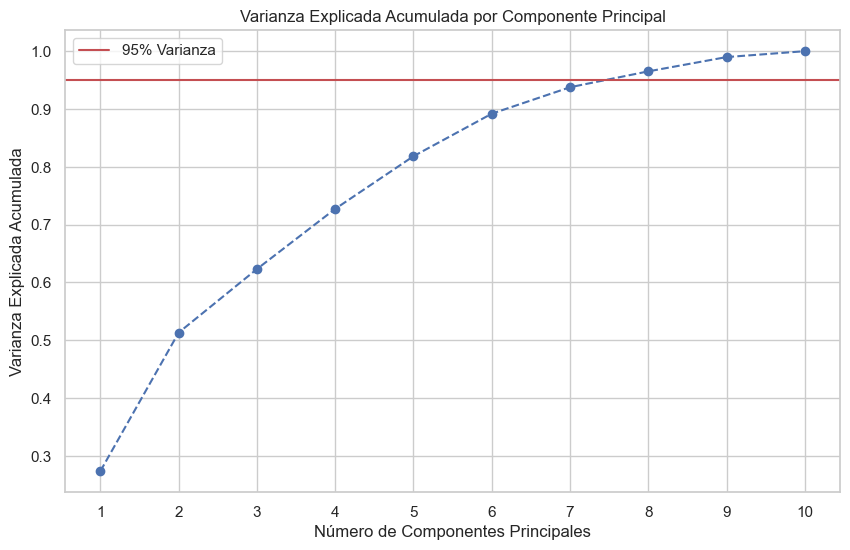

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_components + 1), varianza_acumulada, marker='o', linestyle='--', color='b')
plt.title('Varianza Explicada Acumulada por Componente Principal')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.xticks(range(1, n_components + 1))
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Varianza') # Línea de referencia
plt.legend()
plt.show()

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

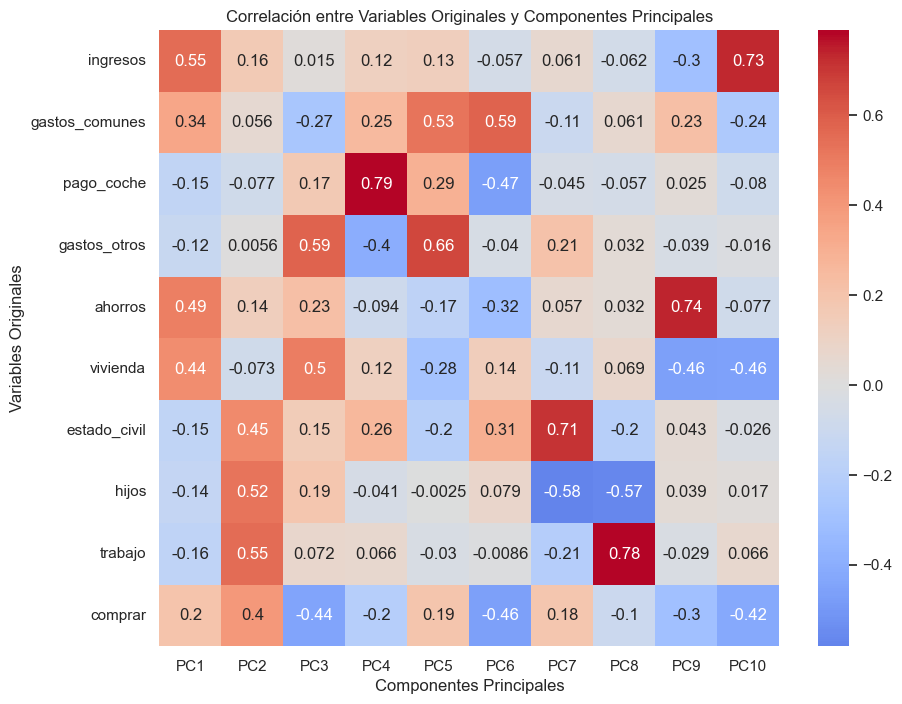

In [23]:
# Los componentes están en pca.components_
# Creamos un DataFrame para visualizarlo mejor
comp_df = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(n_components)], index=features.columns)

plt.figure(figsize=(10, 8))
sns.heatmap(comp_df, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación entre Variables Originales y Componentes Principales')
plt.ylabel('Variables Originales')
plt.xlabel('Componentes Principales')
plt.show()

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [24]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, stratify=target)

In [25]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('clf', LogisticRegression())
])

In [26]:
param_grid = {
    'pca__n_components': [2, 3, 4, 5],
    'clf__C': [0.1, 1, 10]
}

In [27]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [28]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'pca__n_components': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

In [29]:
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor Accuracy en Validación Cruzada (Train): {grid_search.best_score_:.4f}")


Mejores parámetros: {'clf__C': 10, 'pca__n_components': 4}
Mejor Accuracy en Validación Cruzada (Train): 0.9857


In [30]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [31]:
acc_test = accuracy_score(y_test, y_pred)
print(f"Accuracy en Test: {acc_test:.4f}")

Accuracy en Test: 0.9672


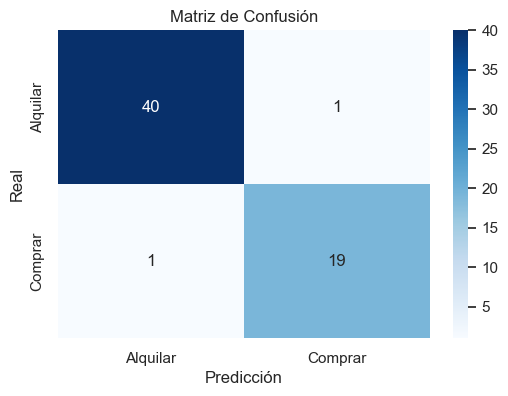

In [32]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Alquilar', 'Comprar'], yticklabels=['Alquilar', 'Comprar'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [33]:
import pickle

with open('mejor_modelo_pca.pkl', 'wb') as archivo_salida:
    pickle.dump(best_model, archivo_salida)